# Análisis de Reseñas: `dice.fm`
**Sector:** Events & Entertainment

**Objetivos:**
1. ¿Las reseñas de `dice.fm` son mayoritariamente positivas o negativas? ¿Y la competencia?
2. ¿Qué temas tratan las reseñas?
3. Para cada tema, ¿el sentimiento es positivo o negativo? ¿En qué somos mejores/peores?
4. Identificar áreas de mejora


DICE.fm es una plataforma y aplicación móvil líder para la venta de entradas de conciertos y eventos en directo.

## 1. Importación de librerías



In [39]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from transformers import pipeline
from collections import Counter


## 2. Configuración


In [42]:
MAX_ROWS   = None 
TARGET     = 'dice.fm'
CAT        = 'Events & Entertainment'
N_TOPICS   = 6
TOP_WORDS  = 10
SENT_MODEL = 'lxyuan/distilbert-base-multilingual-cased-sentiments-student'

# Etiquetas de temas (ajustar tras ver output de NMF)
TOPIC_LABELS = {
    0: 'Compra / Booking',
    1: 'Atención al cliente',
    2: 'Reembolsos / Cancelaciones',
    3: 'Experiencia en evento',
    4: 'App / Plataforma',
    5: 'Entrega / Confirmación',
}
# ⚠️ Revisa las palabras clave de cada topic (celda 'Imprimir Topics')
#    y actualiza TOPIC_LABELS antes de ejecutar las celdas de visualización.

## 3. Carga y filtrado de datos


In [3]:
df = pd.read_csv('trustpilot-reviews-123k.csv')
if MAX_ROWS:
    df = df.head(MAX_ROWS)
print(f'Filas totales: {len(df):,}')
print(f'Empresas: {df["company"].nunique():,} | Sectores: {df["category"].nunique()}')
df.head(3)

Filas totales: 123,181
Empresas: 1,680 | Sectores: 22


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


In [4]:
sector_df = df[df['category'] == CAT].copy().reset_index(drop=True)
target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)

print(f"Sector '{CAT}': {len(sector_df):,} reseñas | {sector_df['company'].nunique()} empresas")
print(f"Target '{TARGET}': {len(target_df):,} reseñas")
print(f"Competencia: {len(comp_df):,} reseñas | {comp_df['company'].nunique()} empresas")
print(f"\nEmpresas del sector:")
print(sector_df['company'].value_counts().to_string())

Sector 'Events & Entertainment': 5,298 reseñas | 76 empresas
Target 'dice.fm': 100 reseñas
Competencia: 5,198 reseñas | 75 empresas

Empresas del sector:
company
www.shopto.net                      100
www.buyagift.co.uk                  100
www.londontheatre.co.uk             100
omaze.co.uk                         100
www.redletterdays.co.uk             100
www.lovetheatre.com                 100
www.fanatical.com                   100
www.ticketmaster.co.uk              100
www.atgtickets.com                  100
www.twickets.live                   100
www.virginexperiencedays.co.uk      100
www.funkypigeon.com                 100
www.attractiontickets.com           100
www.seetickets.com                  100
www.lovehoney.co.uk                 100
seatunique.com                      100
www.gigsandtours.com                100
dice.fm                             100
fanpass.co.uk                       100
stubhub.co.uk                       100
www.ents24.com                      10

## 4. Exploración inicial (EDA)


  Antes de entrar en los modelos NLP hacemos una inspección estructural del dataset: tipos de datos, tamaños y valores
  nulos. Esto nos confirma con qué columnas vamos a trabajar y qué información tenemos disponible.

  **Columnas de interés:**
  - `review` — texto principal de cada reseña (será la entrada de los modelos)
  - `title` — título corto de la reseña
  - `category` — sector de la empresa
  - `company` — nombre de la empresa

In [13]:
# Estructura general del dataset
print('=== Dataset completo ===')
print(f'  Filas:    {len(df):,}')
print(f'  Columnas: {list(df.columns)}')
print()

print('=== Tipos de datos ===')
print(df.dtypes.to_string())
print()

print('=== Valores nulos por columna ===')
print(df.isnull().sum().to_string())


=== Dataset completo ===
  Filas:    123,181
  Columnas: ['category', 'company', 'description', 'title', 'review', 'stars']

=== Tipos de datos ===
category         str
company          str
description      str
title            str
review           str
stars          int64

=== Valores nulos por columna ===
category       0
company        0
description    0
title          0
review         0
stars          0


In [16]:
# Subset que vamos a analizar
print(f'=== Subsets de trabajo ===')
print(f'  Sector "{CAT}":')
print(f'    · Reseñas:  {len(sector_df):,}')
print(f'    · Empresas: {sector_df["company"].nunique()}')
print()
print(f'  Target "{TARGET}":')
print(f'    · Reseñas: {len(target_df):,}')
print(f'    · Nulos en review: {target_df["review"].isnull().sum()}')
print(f'    · Nulos en title:  {target_df["title"].isnull().sum()}')
print()
print(f'=== Muestra: primeras 3 reseñas de {TARGET} ===')
print(target_df[['company', 'title', 'review']].head(3).to_string(index=False))

=== Subsets de trabajo ===
  Sector "Events & Entertainment":
    · Reseñas:  5,298
    · Empresas: 76

  Target "dice.fm":
    · Reseñas: 100
    · Nulos en review: 0
    · Nulos en title:  0

=== Muestra: primeras 3 reseñas de dice.fm ===
company                                             title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              review
dice.fm                           The Past and the Future                                                            I Clock DVA di Sheffield. Siamo alla fine degli anni '80. Alfieri dell'Industrial mu

#### 1. Distribución de longitud de reseñas
¿Son las reseñas de dice.fm más cortas o más largas en comparación con las del resto del sector?

C:\Users\vicho\AppData\Local\Temp\ipykernel_19904\3225822285.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, labels=[TARGET, 'Sector'],


Longitud media — dice.fm: 63.5 palabras
Longitud media — Sector:  63.8 palabras
Mediana — dice.fm: 56 palabras
Mediana — Sector:  53 palabras


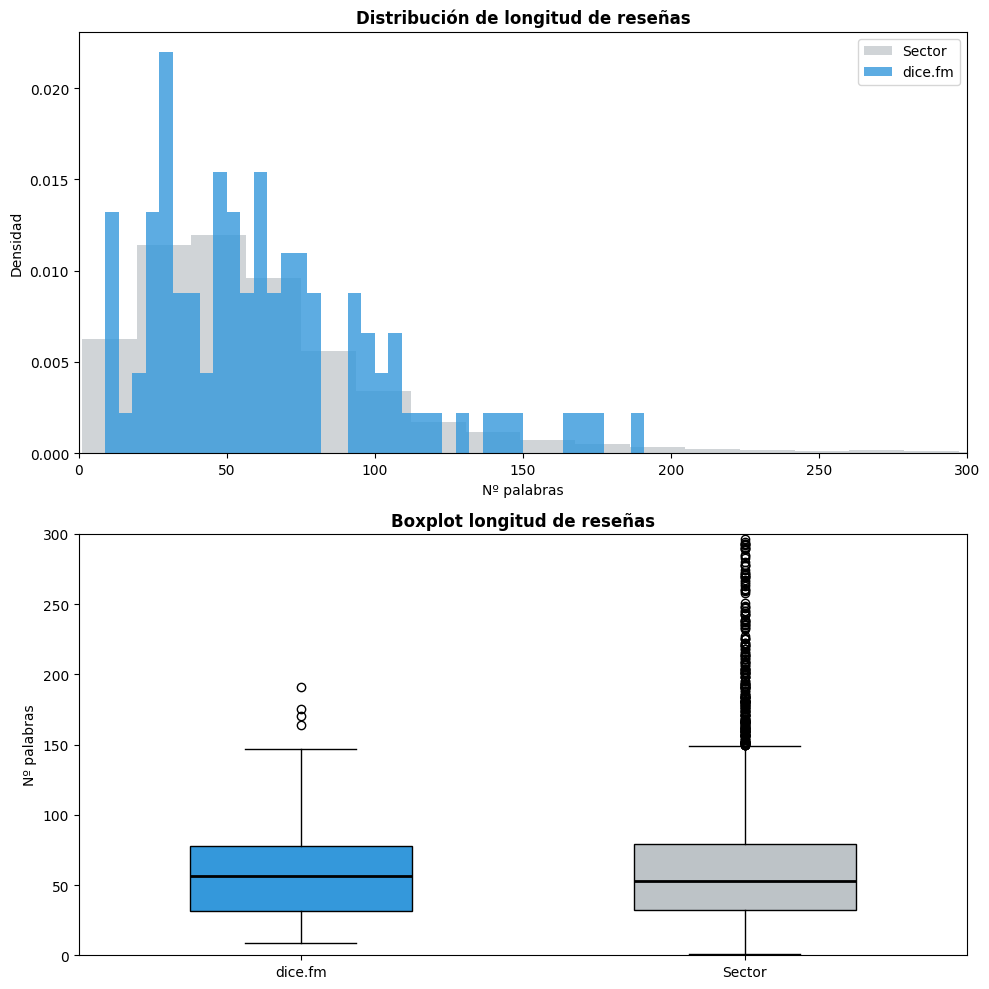

In [29]:
# Longitud de reseñas (palabras)
target_df['n_words'] = target_df['review'].astype(str).str.split().str.len()
sector_sin_target = sector_df[sector_df['company'] != TARGET].copy()
sector_sin_target['n_words'] = sector_sin_target['review'].astype(str).str.split().str.len()

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Histograma
axes[0].hist(sector_sin_target['n_words'], bins=40, color='#bdc3c7',
            alpha=0.7, label='Sector', density=True)
axes[0].hist(target_df['n_words'], bins=40, color='#3498db',
            alpha=0.8, label=TARGET, density=True)
axes[0].set_xlabel('Nº palabras')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de longitud de reseñas', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 300)

# Boxplot
data_box = [target_df['n_words'], sector_sin_target['n_words']]
bp = axes[1].boxplot(data_box, labels=[TARGET, 'Sector'],
                    patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#bdc3c7')
axes[1].set_ylabel('Nº palabras')
axes[1].set_title('Boxplot longitud de reseñas', fontweight='bold')
axes[1].set_ylim(0, 300)

# Estadisticas
print(f"Longitud media — {TARGET}: {target_df['n_words'].mean():.1f} palabras")
print(f"Longitud media — Sector:  {sector_sin_target['n_words'].mean():.1f} palabras")
print(f"Mediana — {TARGET}: {target_df['n_words'].median():.0f} palabras")
print(f"Mediana — Sector:  {sector_sin_target['n_words'].median():.0f} palabras")

plt.tight_layout()
plt.show()

#### 2. Top palabras más frecuentes (dice.fm)

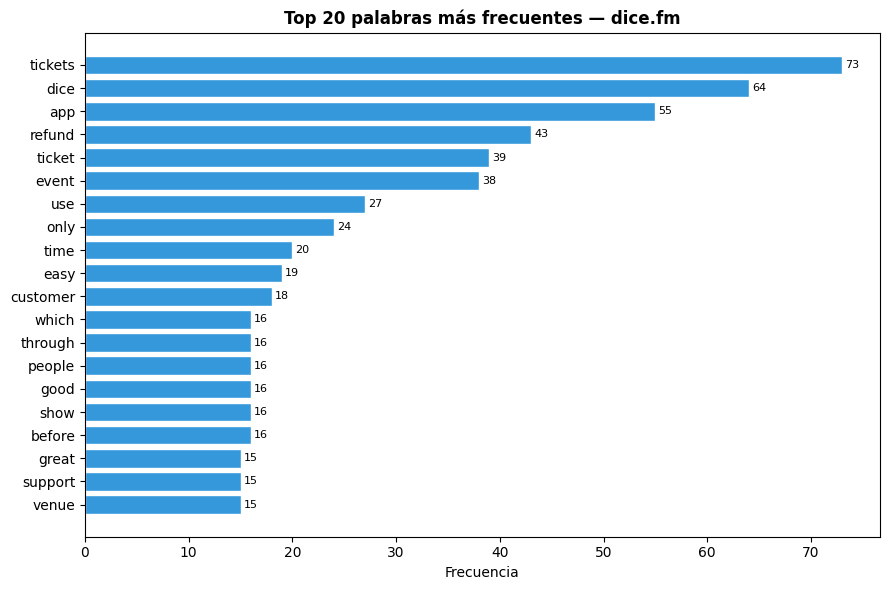

In [31]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','of','to','for','is','it',
    'was','my','i','with','that','this','at','not','they','have','had',
    'be','as','by','we','are','from','so','all','been','has','me','he',
    'she','you','our','their','were','its','if','out','no','up','what',
    'there','when','would','get','did','do','got','just','about','very',
    'his','her','more','one','than','can','will','could','your','some'
}

def top_words(texts, n=20):
    words = []
    for t in texts:
        for w in str(t).lower().split():
            w = w.strip('.,!?;:\'"()-')
            if len(w) > 2 and w not in STOPWORDS:
                words.append(w)
    return Counter(words).most_common(n)

top_target = top_words(target_df['review'], n=20)
words, counts = zip(*top_target)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(words[::-1], counts[::-1], color='#3498db', edgecolor='white')
ax.set_xlabel('Frecuencia')
ax.set_title(f'Top 20 palabras más frecuentes — {TARGET}', fontweight='bold')
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Exploración de caracteres y limpieza de texto


In [43]:
sample = target_df['review'].astype(str)
print('Análisis de caracteres en reseñas de', TARGET,':')
print(f'  URLs presentes:        {sample.str.contains(r"http|www", case=False).sum()}')
print(f'  No-ASCII (emojis, símbolos, acentos...): {sample.str.contains(r"[^\x00-\x7F]").sum()}')
print(f'  Contienen números:     {sample.str.contains(r"\d").sum()}')
print(f'  HTML tags:             {sample.str.contains(r"<[a-z]").sum()}')
print(f'  Longitud media:        {sample.str.len().mean():.0f} caracteres')
print(f'  Longitud mediana:      {sample.str.len().median():.0f} caracteres')

Análisis de caracteres en reseñas de dice.fm :
  URLs presentes:        0
  No-ASCII (emojis, símbolos, acentos...): 28
  Contienen números:     28
  HTML tags:             0
  Longitud media:        348 caracteres
  Longitud mediana:      312 caracteres


He visto que hay reseñas en varios idiomas como por ejemplo en italiano (no todas están en ingles), por tanto, voy a utilizar una función de limpieza del texto que sea compatible con varios idiomas.

In [45]:
def clean_text(text):
    """Normaliza y limpia una reseña — compatible con cualquier idioma."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)       # URLs
    text = re.sub(r'<[^>]+>', ' ', text)                # HTML tags
    text = re.sub(r'@\w+|#\w+', ' ', text)              # menciones y hashtags
    text = re.sub(r'\d+', ' ', text)                    # números
    text = re.sub(r'[^\w\s]', ' ', text)                # puntuación (conserva letras Unicode)
    text = re.sub(r'\s+', ' ', text).strip()            # espacios extra
    text = ' '.join(w for w in text.split() if len(w) > 2)
    return text

# Verificación
orig  = target_df['review'].iloc[0]
clean = clean_text(orig)
print('ORIGINAL:\n', orig[:300])
print('\nLIMPIO:\n', clean[:300])

ORIGINAL:
 I Clock DVA di Sheffield. Siamo alla fine degli anni '80. Alfieri dell'Industrial music. Consumai letteralmente il vinile "Thirst" redo del 1981 seguito da "Advantage" Poi li ho persi di vista intorno alla fine degli anni '90 Quasi 30 anni dopo riscopro un Signore armato di personal Computer:music, 

LIMPIO:
 clock dva sheffield siamo alla fine degli anni alfieri dell industrial music consumai letteralmente vinile thirst redo del seguito advantage poi persi vista intorno alla fine degli anni quasi anni dopo riscopro signore armato personal computer music noise lights stories technologies arts surprisingl


In [48]:
sector_df['clean_review'] = sector_df['review'].apply(clean_text)

# Descartar reseñas vacías tras limpieza
empty = sector_df['clean_review'].str.len() == 0
print(f'Reseñas descartadas (demasiado cortas): {empty.sum()}')
sector_df = sector_df[~empty].reset_index(drop=True)

target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)

print(f'Reseñas limpias — {TARGET}: {len(target_df)}')
print(f'Reseñas limpias — sector:  {len(sector_df):,}')

Reseñas descartadas (demasiado cortas): 0
Reseñas limpias — dice.fm: 100
Reseñas limpias — sector:  5,296


## 6. Análisis de Sentimiento
Utilizamos el modelo **DistilBERT multilingüe** fine-tuned para clasificación de sentimiento,
compatible con 27 idiomas (inglés, italiano, francés, alemán, español...).

Devuelve tres clases: `positive`, `neutral` y `negative`.


In [49]:
print(f'Cargando modelo: {SENT_MODEL} ...')
sent_pipe = pipeline(
    'text-classification',
    model=SENT_MODEL,
    truncation=True,
    max_length=512,
    device=-1   # CPU; cambiar a 0 si hay GPU disponible
)

def batch_sentiment(texts, pipe=sent_pipe, batch_size=64):
    """Aplica el pipeline de sentimiento en batches."""
    texts   = [str(t)[:2000] for t in texts]
    results = []
    for i in range(0, len(texts), batch_size):
        preds = pipe(texts[i:i+batch_size], truncation=True, max_length=512)
        results.extend(preds)
    return results

print('Pipeline listo ✓')

Cargando modelo: lxyuan/distilbert-base-multilingual-cased-sentiments-student ...


config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

c:\Users\vicho\PROYECTOS\NLP_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vicho\.cache\huggingface\hub\models--lxyuan--distilbert-base-multilingual-cased-sentiments-student. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Pipeline listo ✓


In [50]:
print(f'Procesando {len(sector_df):,} reseñas del sector (puede tardar varios minutos)...')
all_preds = batch_sentiment(sector_df['clean_review'].tolist())

sector_df['sentiment']   = [p['label'] for p in all_preds]
sector_df['sent_score']  = [
    p['score'] if p['label'] == 'positive' else 1 - p['score']
    for p in all_preds
]
sector_df['is_positive'] = (sector_df['sentiment'] == 'positive').astype(int)

target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)

pct_t = target_df['is_positive'].mean() * 100
pct_s = comp_df['is_positive'].mean()   * 100
print(f'\n{"-"*45}')
print(f'% Positivo  {TARGET:<22}: {pct_t:.1f}%')
print(f'% Positivo  Sector (sin target): {pct_s:.1f}%')
print(f'{"-"*45}')

Procesando 5,296 reseñas del sector (puede tardar varios minutos)...

---------------------------------------------
% Positivo  dice.fm               : 43.0%
% Positivo  Sector (sin target): 46.4%
---------------------------------------------


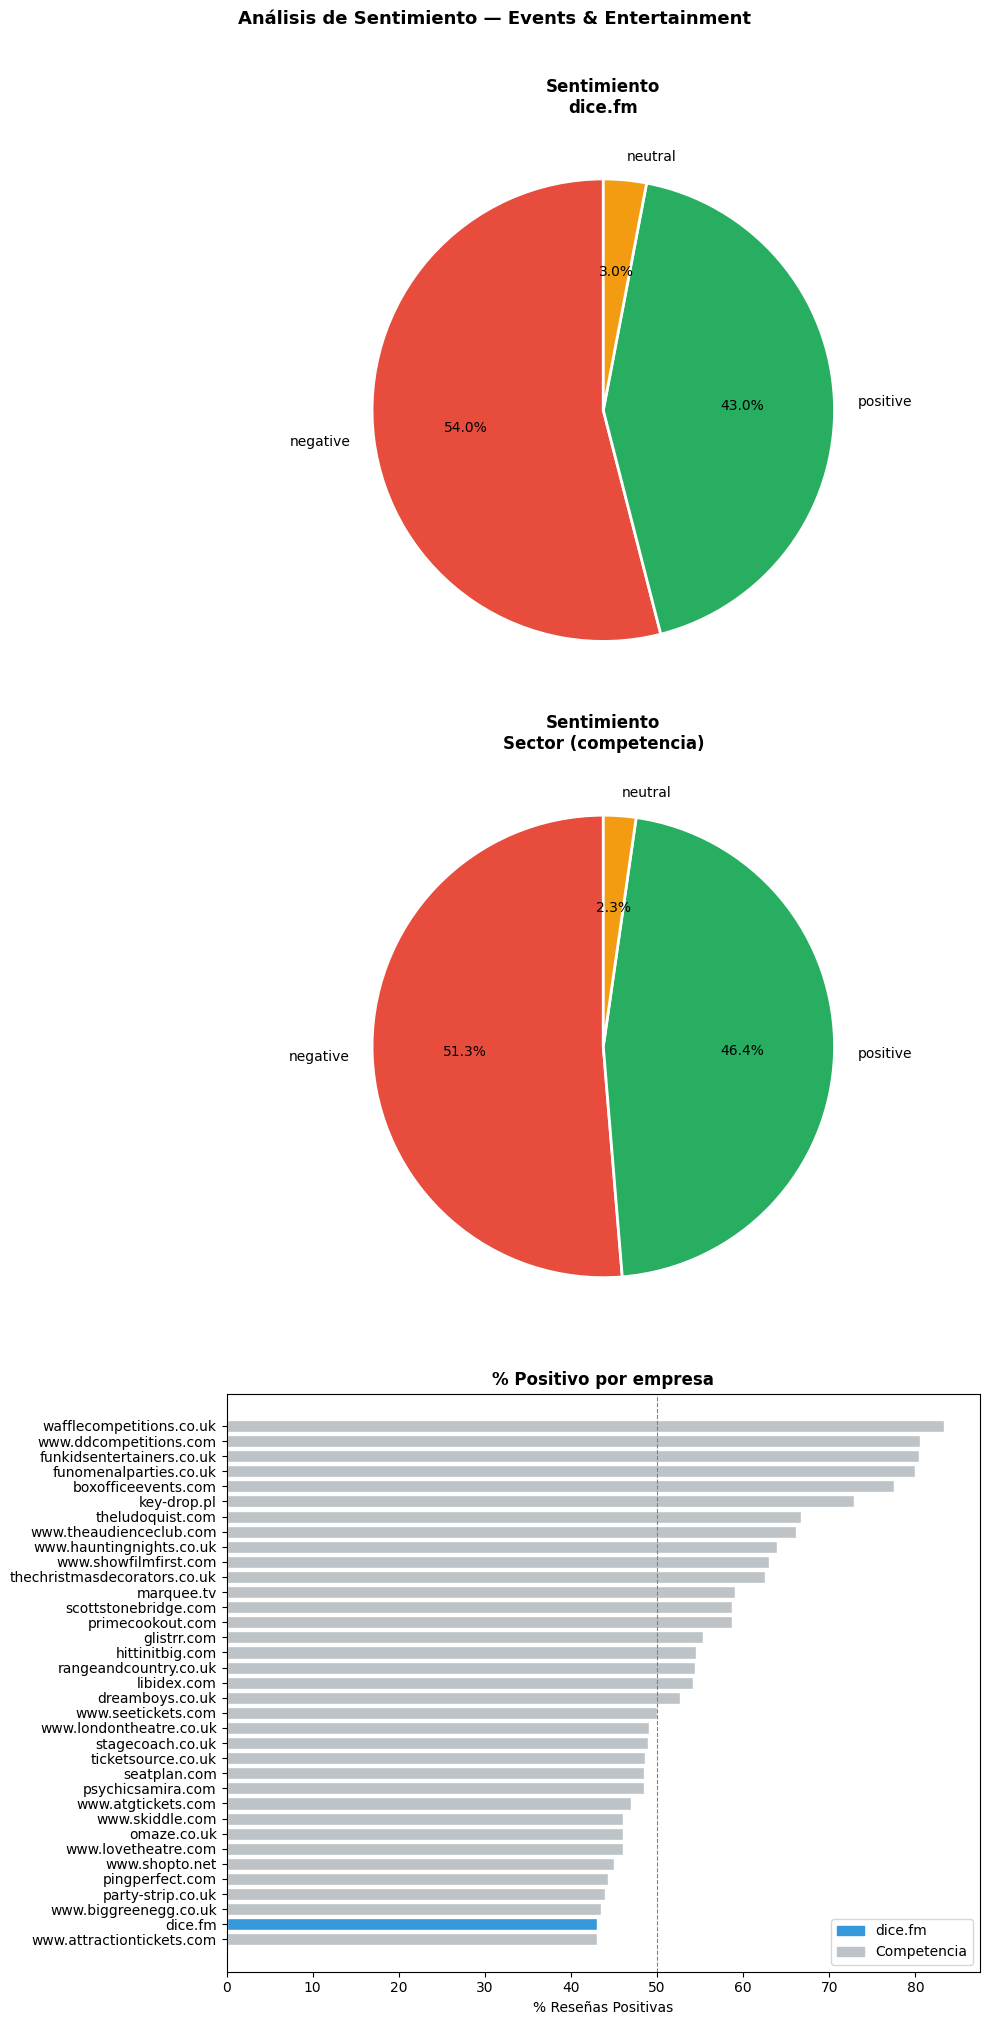

In [69]:
fig, axes = plt.subplots(3, 1, figsize=(10, 20))

def color_sentiment(label):
      if label == 'positive': return '#27ae60'
      if label == 'negative': return '#e74c3c'
      return '#f39c12'

# Pie TARGET
vc_t = target_df['sentiment'].value_counts()
pie_c_t =  [color_sentiment(l) for l in vc_t.index]
axes[0].pie(vc_t.values, labels=vc_t.index, colors=pie_c_t,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f'Sentimiento\n{TARGET}', fontweight='bold')

# Pie SECTOR
vc_s = comp_df['sentiment'].value_counts()
pie_c_s =  [color_sentiment(l) for l in vc_t.index]
axes[1].pie(vc_s.values, labels=vc_s.index, colors=pie_c_s,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentimiento\nSector (competencia)', fontweight='bold')

# Barras: % positivo por empresa
co_sent = (
    sector_df.groupby('company')['is_positive']
    .agg(pct_pos='mean', n='count')
    .query('n >= 30')
    .assign(pct_pos=lambda x: x['pct_pos'] * 100)
    .sort_values('pct_pos', ascending=True)
    .tail(35)
)
bar_c2 = ['#3498db' if c == TARGET else '#bdc3c7' for c in co_sent.index]
axes[2].barh(co_sent.index, co_sent['pct_pos'], color=bar_c2, edgecolor='white')
axes[2].axvline(50, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('% Reseñas Positivas')
axes[2].set_title('% Positivo por empresa', fontweight='bold')
p1 = mpatches.Patch(color='#3498db', label=TARGET)
p2 = mpatches.Patch(color='#bdc3c7', label='Competencia')
axes[2].legend(handles=[p1, p2])

plt.suptitle('Análisis de Sentimiento — Events & Entertainment',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [70]:
co_rank = (
    sector_df.groupby('company')
    .agg(pct_positivo=('is_positive', 'mean'),
        n_reviews=('review', 'count'))
    .query('n_reviews >= 30')
    .assign(pct_positivo=lambda x: (x['pct_positivo'] * 100).round(1))
    .sort_values('pct_positivo', ascending=False)
)
print('=== Ranking empresas por % reseñas positivas ===')
print(co_rank.to_string())
if TARGET in co_rank.index:
    rank = list(co_rank.index).index(TARGET) + 1
    print(f'\n{TARGET} → puesto {rank} de {len(co_rank)}')

=== Ranking empresas por % reseñas positivas ===
                                  pct_positivo  n_reviews
company                                                  
wafflecompetitions.co.uk                  83.3         30
www.ddcompetitions.com                    80.5         41
funkidsentertainers.co.uk                 80.4         46
funomenalparties.co.uk                    80.0         35
boxofficeevents.com                       77.6         49
key-drop.pl                               72.8         92
theludoquist.com                          66.7         39
www.theaudienceclub.com                   66.2         65
www.hauntingnights.co.uk                  63.9         36
www.showfilmfirst.com                     63.0         81
thechristmasdecorators.co.uk              62.5         32
marquee.tv                                59.0         83
scottstonebridge.com                      58.7         63
primecookout.com                          58.7         46
glistrr.com            

## 7. Topic Modeling — NMF
Aplicamos **TF-IDF + NMF** sobre todas las reseñas del sector para obtener temas comparables entre empresas.


In [ ]:
print('Construyendo matriz TF-IDF del sector...')
tfidf_vec = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.85,
    stop_words='english',
    ngram_range=(1, 2),
    token_pattern=r'\b[a-z][a-z]{2,}\b'
)
tfidf_matrix = tfidf_vec.fit_transform(sector_df['clean_review'])
feat_names   = tfidf_vec.get_feature_names_out()
print(f'Vocabulario: {len(feat_names):,} términos | Matriz: {tfidf_matrix.shape}')

print(f'Ajustando NMF con {N_TOPICS} componentes...')
nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=500, l1_ratio=0.1)
W   = nmf.fit_transform(tfidf_matrix)   # doc × topic
H   = nmf.components_                   # topic × word

sector_df['topic']       = W.argmax(axis=1)
sector_df['topic_weight'] = W.max(axis=1)

target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)
print('NMF completado ✓')

In [ ]:
print('=== TOPICS detectados (sector Events & Entertainment) ===')
print('(Usa estas palabras clave para actualizar TOPIC_LABELS en la celda de Configuración)\n')
for i, row in enumerate(H):
    top_idx   = row.argsort()[-TOP_WORDS:][::-1]
    top_words = ' | '.join(feat_names[j] for j in top_idx)
    print(f'Topic {i}: {top_words}')
print()

print(f'Distribución de topics en {TARGET}:')
print(target_df['topic'].value_counts().sort_index())

In [ ]:
# Aplica etiquetas (actualiza TOPIC_LABELS arriba si es necesario)
sector_df['topic_label'] = sector_df['topic'].map(TOPIC_LABELS)
target_df = sector_df[sector_df['company'] == TARGET].copy().reset_index(drop=True)
comp_df   = sector_df[sector_df['company'] != TARGET].copy().reset_index(drop=True)

print(f'Topics en {TARGET}:')
for lbl, cnt in target_df['topic_label'].value_counts().items():
    print(f'  {lbl}: {cnt} reseñas ({cnt/len(target_df)*100:.1f}%)')

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes  = axes.flatten()
cmap  = plt.cm.Set2(np.linspace(0, 1, N_TOPICS))

for t_idx in range(N_TOPICS):
    ax     = axes[t_idx]
    vec    = H[t_idx]
    top_i  = vec.argsort()[-8:][::-1]
    words  = [feat_names[j] for j in top_i]
    wts    = [vec[j] for j in top_i]
    ax.barh(words[::-1], wts[::-1], color=cmap[t_idx], edgecolor='white')
    ax.set_title(TOPIC_LABELS.get(t_idx, f'Topic {t_idx}'), fontweight='bold', fontsize=10)
    ax.set_xlabel('Peso NMF')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle(f'Palabras clave por tema — Sector {CAT}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución TARGET
t_dist = (target_df['topic_label'].value_counts() / len(target_df) * 100).sort_values(ascending=True)
axes[0].barh(t_dist.index, t_dist.values, color='#3498db', edgecolor='white')
axes[0].set_xlabel('% de reseñas')
axes[0].set_title(f'Distribución de Temas — {TARGET}', fontweight='bold')

# TARGET vs SECTOR
c_dist = comp_df['topic_label'].value_counts() / len(comp_df) * 100
cmp_df = pd.DataFrame({
    TARGET: target_df['topic_label'].value_counts() / len(target_df) * 100,
    'Sector': c_dist
}).fillna(0).sort_values(TARGET, ascending=True)

y = np.arange(len(cmp_df))
w = 0.35
axes[1].barh(y - w/2, cmp_df[TARGET],   w, label=TARGET,   color='#3498db', edgecolor='white')
axes[1].barh(y + w/2, cmp_df['Sector'], w, label='Sector', color='#bdc3c7', edgecolor='white')
axes[1].set_yticks(y)
axes[1].set_yticklabels(cmp_df.index, fontsize=9)
axes[1].set_xlabel('% de reseñas')
axes[1].set_title(f'Temas: {TARGET} vs Sector', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Sentimiento por Tema


In [ ]:
sent_by_topic_t = (
    target_df.groupby('topic_label')['is_positive']
    .agg(pct_pos='mean', n='count')
    .assign(pct_pos=lambda x: (x['pct_pos'] * 100).round(1),
            pct_neg=lambda x: (100 - x['pct_pos']).round(1))
    .sort_values('pct_pos', ascending=False)
)
sent_by_topic_s = (
    comp_df.groupby('topic_label')['is_positive']
    .agg(pct_pos='mean', n='count')
    .assign(pct_pos=lambda x: (x['pct_pos'] * 100).round(1))
)
print(f'=== Sentimiento por tema — {TARGET} ===')
print(sent_by_topic_t[['pct_pos', 'pct_neg', 'n']].to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar TARGET
st_sorted = sent_by_topic_t.sort_values('pct_pos')
axes[0].barh(st_sorted.index, st_sorted['pct_pos'], color='#27ae60', label='Positivo', edgecolor='white')
axes[0].barh(st_sorted.index, st_sorted['pct_neg'], left=st_sorted['pct_pos'],
             color='#e74c3c', label='Negativo', edgecolor='white')
axes[0].axvline(50, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('% Reseñas')
axes[0].set_title(f'Sentimiento por Tema — {TARGET}', fontweight='bold')
axes[0].legend(loc='lower right')

# Heatmap TARGET vs SECTOR
hm_data = pd.DataFrame({
    TARGET: sent_by_topic_t['pct_pos'],
    'Sector': sent_by_topic_s['pct_pos']
}).dropna()
sns.heatmap(hm_data, ax=axes[1], annot=True, fmt='.1f',
            cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% Positivo'})
axes[1].set_title(f'% Positivo por Tema: {TARGET} vs Sector', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 9. Comparativa con la competencia


In [ ]:
# Sentimiento por tema: dice.fm vs media del sector
comp_summary = pd.DataFrame({
    TARGET:   sent_by_topic_t['pct_pos'],
    'Sector': sent_by_topic_s['pct_pos']
}).dropna().round(1)
comp_summary['gap'] = (comp_summary[TARGET] - comp_summary['Sector']).round(1)

print(f'=== {TARGET} vs Media del Sector (% positivo) ===')
print(comp_summary.to_string())
print()
print('FORTALEZAS (mejor que el sector):')
for topic, row in comp_summary[comp_summary['gap'] > 0].sort_values('gap', ascending=False).iterrows():
    print(f'  ▲ {topic}: {row[TARGET]}% vs {row["Sector"]}% sector (+{row["gap"]}%)')
print('\nDEBILIDADES / ÁREAS DE MEJORA:')
for topic, row in comp_summary[comp_summary['gap'] < 0].sort_values('gap').iterrows():
    print(f'  ▼ {topic}: {row[TARGET]}% vs {row["Sector"]}% sector ({row["gap"]}%)')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar: target vs sector por tema
topics_list = comp_summary.index.tolist()
x = np.arange(len(topics_list))
w = 0.35
axes[0].bar(x - w/2, comp_summary[TARGET], w, label=TARGET, color='#3498db', edgecolor='white')
axes[0].bar(x + w/2, comp_summary['Sector'], w, label='Media Sector', color='#bdc3c7', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(topics_list, rotation=25, ha='right', fontsize=9)
axes[0].set_ylabel('% Positivo')
axes[0].axhline(50, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title(f'% Positivo por Tema: {TARGET} vs Sector', fontweight='bold')
axes[0].legend()

# GAP chart
gap_sorted = comp_summary['gap'].sort_values()
colors_gap = ['#27ae60' if v >= 0 else '#e74c3c' for v in gap_sorted.values]
axes[1].barh(gap_sorted.index, gap_sorted.values, color=colors_gap, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel(f'Gap {TARGET} − Sector (%)')
axes[1].set_title(f'Diferencia respecto al sector', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Reseñas negativas representativas por tema


In [ ]:
print(f'=== Reseñas negativas representativas de {TARGET} ===\n')
for topic_idx in range(N_TOPICS):
    lbl = TOPIC_LABELS.get(topic_idx, f'Topic {topic_idx}')
    neg = target_df[
        (target_df['topic'] == topic_idx) &
        (target_df['sentiment'] == 'NEGATIVE')
    ]['review']
    if len(neg) == 0:
        continue
    print(f'--- {lbl} ({len(neg)} reseñas negativas) ---')
    for rev in neg.sample(min(2, len(neg)), random_state=42):
        print(f'  "{str(rev)[:280]}"')
    print()

## 11. Conclusiones

*(Completar tras ejecutar el notebook con los resultados reales)*

### Hipótesis de partida
- **H1**: Las reseñas de `dice.fm` son mayoritariamente positivas (plataforma consolidada).
- **H2**: Los temas principales serán: compra de entradas, atención al cliente y reembolsos.
- **H3**: Las quejas se concentrarán en reembolsos y soporte (sector eventos).

### Resultados esperados
| Dimensión | dice.fm | Sector |
|---|---|---|
| % Positivo global | *(completar)* | *(completar)* |
| Media estrellas | *(completar)* | *(completar)* |
| Tema más frecuente | *(completar)* | — |
| Mejor tema (gap +) | *(completar)* | — |
| Peor tema (gap −) | *(completar)* | — |

### Áreas de mejora identificadas
1. *(completar con el topic de menor % positivo)*
2. *(completar)*

### Conclusión final
> *(Redactar 3-4 frases con los hallazgos principales: posición relativa de dice.fm en el sector,
> fortalezas, debilidades y recomendaciones.)*
